# Here we create 10 real, 10 synthetic samples to see if a human analyst could discriminate between the two classes

In [ ]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

In [72]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard
from DNAnet.data.parsing.file_parsing import find_files_by_suffix
import matplotlib.pyplot as plt
import numpy as np
import os

from typing import List
from pathlib import Path

# Create HID Image

In [ ]:
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"

In [ ]:
panel = Panel(gf_panel_path)
hid_files = find_files_by_suffix(hid_files_path, ".hid")
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

In [ ]:
# randomly select n files from the hid_files
import random
selected_files = random.sample(hid_files, 50)

In [ ]:
len(selected_files)

In [ ]:
images = CustomHIDDataset(
    files=selected_files,
    panel=panel,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

### Visualization

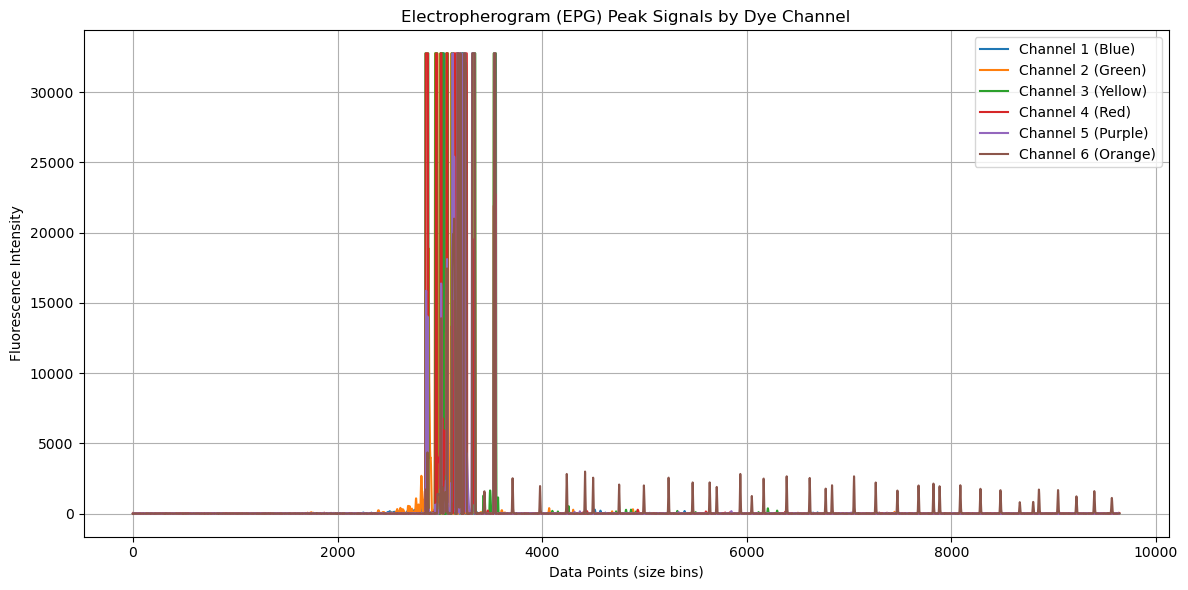

In [73]:
from DNAnet.data.parsing.parse_raw_hid import get_peak_data

image = images[0]  # Get the first image from the dataset

epg = get_peak_data(image.path) # shape: (6, 9642)

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))
    dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple', 'Orange']  # Optional: adjust per your kit

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'Channel {i+1} ({dye_labels[i]})')

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals by Dye Channel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_epg_together(epg)
# plot_epg_together(annotation_image_mock_data)

In [68]:
# Plotting function for EPG
def plot_epg(epg: np.ndarray, no_dyes=6, title="EPG", save_path='epg', include_lane_standard=True):
    lane_colors = ["magenta", "blue", "cyan", "green", "yellow", "orange"]
    lanes = no_dyes if include_lane_standard else no_dyes - 1
    
    fig, axes = plt.subplots(lanes, 1, figsize=(14, 2.5 * lanes), sharex=True)
    if lanes == 1:
        axes = [axes]
    for i in range(lanes):
        axes[i].plot(epg[0, i, :, 0], color=lane_colors[i])
        # axes[i].set_title(f"{title} - Lane {i+1}", fontsize=12)
        axes[i].set_ylabel("Intensity")
        axes[i].grid(True)
    axes[-1].set_xlabel("Scan Points")
    fig.suptitle(title, fontsize=16)  # Set a single title for the whole plot
    plt.tight_layout()
    plt.savefig(f"{save_path}.pdf")
    plt.close(fig)
    # plt.show()

In [71]:
output_dir = "/Users/amarmesic/Documents/tudelft/thesis/dna/generated_epgs"
ids = [3, 5, 8, 9, 10, 11, 14, 17, 18, 20]

for image, id in zip(images, ids):
    epg = get_peak_data(image.path)[np.newaxis, :, 4000:9000, np.newaxis]
    # Save all 2 combinations
    epg_type = "real"
    for include_dye in [True, False]:
        dye_str = "dye" if include_dye else "no_dye"
        # Determine subdirectory
        if epg_type == "modelled":
            subdir = "modelled"
        elif epg_type == "real" and include_dye:
            subdir = "ladder"
        else:
            subdir = "no_ladder"
        # Ensure subdirectory exists
        out_subdir = os.path.join(output_dir, subdir)
        os.makedirs(out_subdir, exist_ok=True)
        save_path = f"{out_subdir}/{epg_type}_epg_id_{id}_{dye_str}"
        plot_epg(
            epg,
            no_dyes=6,
            title=f"{epg_type.capitalize()} EPG (ID: {id})",
            save_path=save_path,
            include_lane_standard=include_dye
        )